 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

![mnist_data_sample.png](attachment:eb3e0d6a-ccb0-499d-9847-ecbc554dbce0.png)

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [1]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
###################################
# Write your own code here #


from keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam


###################################
font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 1.2 Dataset examination

Using the following code, display random images,

In [3]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

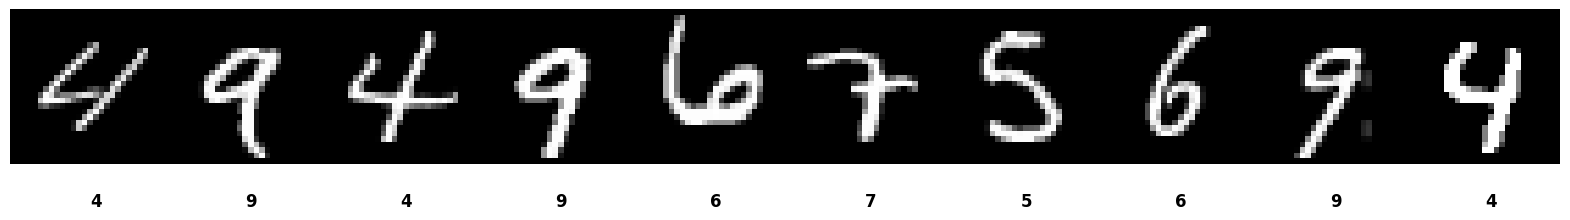

In [5]:
display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [6]:
###################################
# Write your own code here #


(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape para agregar dimensión de canal (28,28) → (28,28,1)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test  = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Normalización (min-max)
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# One-hot encoding de las etiquetas
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)


###################################

### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [7]:
model = Sequential()
###################################
# Write your own code here #


model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


###################################

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem

In [8]:
loss = None
optimizer = None
metrics = None
learning_rate = 0.0

###################################
# Write your own code here #


loss = 'categorical_crossentropy'
optimizer = Adam(learning_rate=0.001)
metrics = ['accuracy']

model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)


###################################
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [ ]:
###################################
# Write your own code here #


history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=1)


###################################

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.8990 - loss: 0.3344 - val_accuracy: 0.9772 - val_loss: 0.0759
Epoch 2/15
 92/375 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.9661 - loss: 0.1052

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

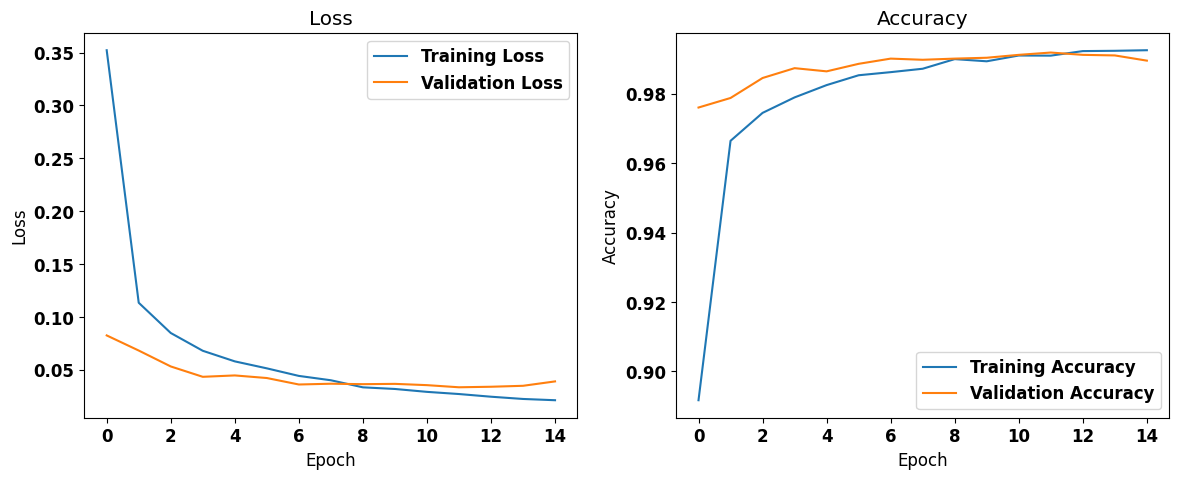

In [ ]:
###################################
# Write your own code here #


plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


###################################

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

Test Loss: 0.0275
Test Accuracy: 99.24%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


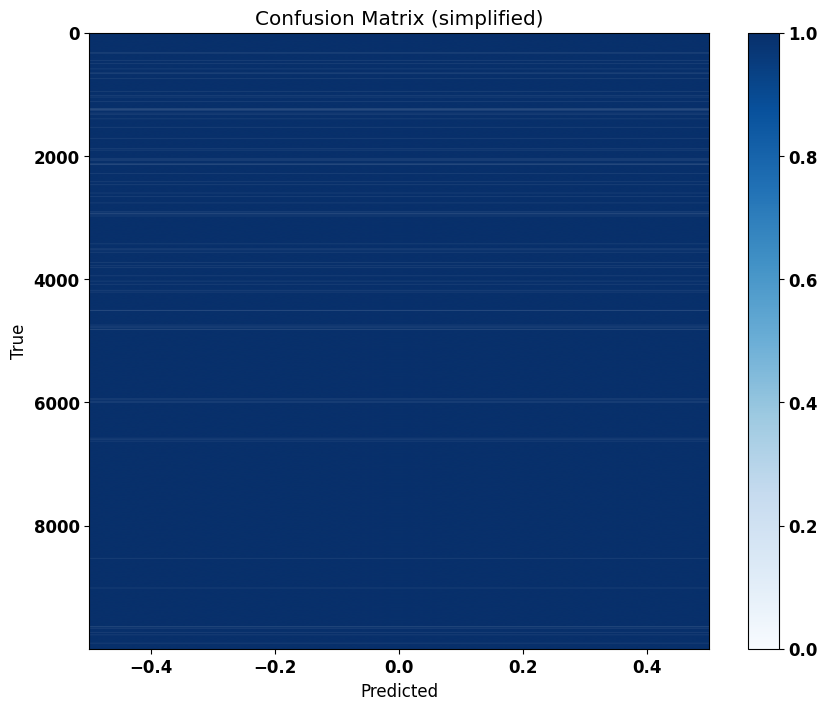


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
###################################
# Write your own code here #


# Evaluación en el conjunto de test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Predicciones para matriz de confusión
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Matriz de confusión (sin seaborn)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.imshow(y_pred_classes.reshape(-1,1) == y_true_classes.reshape(-1,1), cmap='Blues', aspect='auto')
plt.title('Confusion Matrix (simplified)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

# Reporte simple
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))


###################################

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

In [ ]:
###################################
# Write your own code here #


# ==================== EXPERIMENT 1: Modelo base (el que ya tienes) ====================
print("=== Experimento 1: Modelo Base ===")
# (Aquí ya tienes el modelo de la sección 2)

# ==================== EXPERIMENT 2: Más filtros y Dropout extra ====================
print("\n=== Experimento 2: Más filtros + Dropout ===")
model2 = Sequential()

model2.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Conv2D(128, kernel_size=(3,3), activation='relu'))   # capa extra
model2.add(MaxPooling2D(pool_size=(2,2)))

model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(10, activation='softmax'))

model2.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

history2 = model2.fit(X_train, y_train,
                      epochs=12,
                      batch_size=128,
                      validation_split=0.2,
                      verbose=1)

# Evaluación rápida
test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Modelo 2 - Test Accuracy: {test_acc2*100:.2f}%")


# ==================== EXPERIMENT 3: Con regularización L2 ====================
print("\n=== Experimento 3: Regularización L2 ===")
from keras.regularizers import l2

model3 = Sequential()

model3.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model3.add(MaxPooling2D(pool_size=(2,2)))
model3.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model3.add(MaxPooling2D(pool_size=(2,2)))

model3.add(Flatten())
model3.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model3.add(Dropout(0.4))
model3.add(Dense(10, activation='softmax'))

model3.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

history3 = model3.fit(X_train, y_train,
                      epochs=12,
                      batch_size=128,
                      validation_split=0.2,
                      verbose=1)

test_loss3, test_acc3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"Modelo 3 (L2) - Test Accuracy: {test_acc3*100:.2f}%")


# ==================== EXPERIMENT 4: Learning rate más pequeño ====================
print("\n=== Experimento 4: Learning Rate más pequeño ===")
model4 = Sequential()

model4.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model4.add(MaxPooling2D(pool_size=(2,2)))
model4.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model4.add(MaxPooling2D(pool_size=(2,2)))

model4.add(Flatten())
model4.add(Dense(128, activation='relu'))
model4.add(Dropout(0.5))
model4.add(Dense(10, activation='softmax'))

model4.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.0005),   # lr más pequeño
               metrics=['accuracy'])

history4 = model4.fit(X_train, y_train,
                      epochs=15,
                      batch_size=128,
                      validation_split=0.2,
                      verbose=1)

test_loss4, test_acc4 = model4.evaluate(X_test, y_test, verbose=0)
print(f"Modelo 4 (lr=0.0005) - Test Accuracy: {test_acc4*100:.2f}%")


# ==================== Comparación final ====================
print("\n=== Resultados Finales ===")
print(f"Modelo Base      : {test_acc*100:.2f}%")
print(f"Modelo + más capas: {test_acc2*100:.2f}%")
print(f"Modelo + L2       : {test_acc3*100:.2f}%")
print(f"Modelo + lr pequeño: {test_acc4*100:.2f}%")


###################################

=== Experimento 1: Modelo Base ===

=== Experimento 2: Más filtros + Dropout ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.8492 - loss: 0.4750 - val_accuracy: 0.9633 - val_loss: 0.1150
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.9593 - loss: 0.1384 - val_accuracy: 0.9764 - val_loss: 0.0791
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 118ms/step - accuracy: 0.9704 - loss: 0.0999 - val_accuracy: 0.9813 - val_loss: 0.0629
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 121ms/step - accuracy: 0.9775 - loss: 0.0779 - val_accuracy: 0.9817 - val_loss: 0.0610
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.9810 - loss: 0.0641 - val_accuracy: 0.9854 - val_loss: 0.0528
Epoch 6/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.9829 - loss: 0.0554 - val_accuracy: 0.9858 - val_loss: 0.0510
Epoch 7/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 124ms/step - accuracy: 0.9856 - loss: 0.0470 - val_accuracy: 0.9843 - val_loss: 0.0523
Epoch 8/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 117ms/step - accuracy: 0.9885 - loss: 0